In [1]:
!pip install wandb -q

In [2]:
import os, torchvision

# Create folder structure
for folder in [
    "Model/A", "Model/B", "Model/C",
    "Raw/gradients",
    "Results/Graphs",
    "logs/A", "logs/B", "logs/C",
    "data",
]:
    os.makedirs(folder, exist_ok=True)

# Download MNIST
torchvision.datasets.MNIST('./data/', train=True, download=True)
torchvision.datasets.MNIST('./data/', train=False, download=True)
print("Folders created, MNIST downloaded")

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.12MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]

Folders created, MNIST downloaded


In [3]:
import numpy as np
from PIL import Image
import pandas as pd
import random

random.seed(42)
np.random.seed(42)

NUM_GRADIENTS = 1000
GRAD_SIZE = 28  # generate small, resize later

# Generate random gradient images
gradient_paths = []
for i in range(NUM_GRADIENTS):
    # Two random colors
    c1 = np.random.randint(0, 256, size=3)
    c2 = np.random.randint(0, 256, size=3)

    # Linear gradient
    img = np.zeros((GRAD_SIZE, GRAD_SIZE, 3), dtype=np.uint8)
    for row in range(GRAD_SIZE):
        t = row / (GRAD_SIZE - 1)
        img[row, :] = (c1 * (1 - t) + c2 * t).astype(np.uint8)

    path = f"Raw/gradients/grad_{i:04d}.png"
    Image.fromarray(img).save(path)
    gradient_paths.append(path)

# Create pairings: each gradient paired with a random MNIST index
mnist_train = torchvision.datasets.MNIST('./data/', train=True, download=False)
NUM_PAIRS = min(len(mnist_train), 10000)

pairings = []
for i in range(NUM_PAIRS):
    grad_idx = random.randint(0, NUM_GRADIENTS - 1)
    pairings.append({
        "gradient_path": gradient_paths[grad_idx],
        "mnist_idx": i,
    })

df = pd.DataFrame(pairings)
df.to_csv("Raw/pairings.csv", index=False)
print(f"Generated {NUM_GRADIENTS} gradients, {NUM_PAIRS} pairings")
print(df.head())

Generated 1000 gradients, 10000 pairings
                 gradient_path  mnist_idx
0  Raw/gradients/grad_0654.png          0
1  Raw/gradients/grad_0114.png          1
2  Raw/gradients/grad_0025.png          2
3  Raw/gradients/grad_0759.png          3
4  Raw/gradients/grad_0281.png          4


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import os
from pathlib import Path
from sklearn.metrics import classification_report
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [5]:
IMAGE_SIZE = 128          # composite image size (change to 64, 256, etc.)
DIGIT_SIZE = 28           # MNIST original size
CLASSIFIER_SIZE = 28      # LeNet always sees 28×28
BOX_BLUR_KERNEL = max(3, int(9 * IMAGE_SIZE / 28)) | 1
BATCH_SIZE = 32
LR = 1e-3
SEED = 42
ALPHA = -0.5    # weight for pre-blur confidence (negative = penalize recognition)
BETA = 0.5      # weight for post-blur confidence (positive = reward recognition)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"IMAGE_SIZE      = {IMAGE_SIZE}")
print(f"CLASSIFIER_SIZE = {CLASSIFIER_SIZE}")
print(f"BOX_BLUR_KERNEL = {BOX_BLUR_KERNEL}")
print(f"BATCH_SIZE      = {BATCH_SIZE}")
print(f"ALPHA           = {ALPHA}")
print(f"BETA            = {BETA}")

IMAGE_SIZE      = 128
CLASSIFIER_SIZE = 28
BOX_BLUR_KERNEL = 41
BATCH_SIZE      = 32
ALPHA           = -0.5
BETA            = 0.5


In [6]:
class LeNet3channel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1   = nn.Linear(16*5*5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x):
        x = F.avg_pool2d(F.relu(self.conv1(x)), 2)
        x = F.avg_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        return self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))

print("LeNet3channel defined")

LeNet3channel defined


Dataset: 10000 total, using 1280 subset
Sample shape: torch.Size([3, 128, 128]), label: 5, digit at (81, 14)


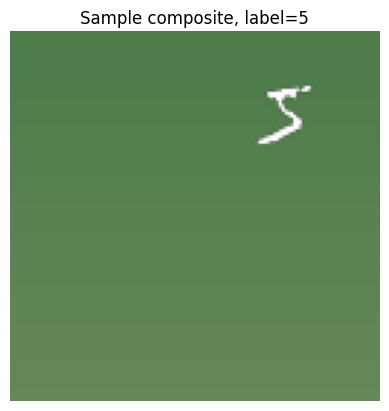

In [7]:
def embed_digit_in_canvas(digit_1ch, canvas_3ch):
    """Embed 28×28 digit at random position. Returns (canvas_digit, x_off, y_off)."""
    C, H, W = canvas_3ch.shape
    _, dh, dw = digit_1ch.shape
    x_off = random.randint(0, W - dw)
    y_off = random.randint(0, H - dh)
    digit_full = torch.zeros(1, H, W)
    digit_full[:, y_off:y_off+dh, x_off:x_off+dw] = digit_1ch
    return digit_full, x_off, y_off


def alpha_combine(b, i_full):
    alpha = i_full.expand_as(b)
    return alpha * i_full.expand_as(b) + (1 - alpha) * b


def additive_combine(b, i_full):
    return b + i_full.expand_as(b)


class CompositeDataset(Dataset):
    def __init__(self, csv_path, combination_type="alpha"):
        self.pairings = pd.read_csv(csv_path)
        self.combination_type = combination_type

        self.bg_transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
        ])
        self.mnist = datasets.MNIST(
            './data/', train=True, download=False,
            transform=transforms.ToTensor(),
        )

    def __len__(self):
        return len(self.pairings)

    def __getitem__(self, idx):
        ann = self.pairings.iloc[idx]
        b = self.bg_transform(Image.open(ann["gradient_path"]).convert("RGB"))
        i, lab = self.mnist[int(ann["mnist_idx"])]
        i_full, x_off, y_off = embed_digit_in_canvas(i, b)

        if self.combination_type == "alpha":
            comp = alpha_combine(b, i_full)
        else:
            comp = additive_combine(b, i_full)
        return comp.clamp(0, 1), lab, x_off, y_off

    def __getitems__(self, indices):
        return [self[i] for i in indices]


# Build dataloaders
full_dataset = CompositeDataset("Raw/pairings.csv", combination_type="alpha")

SUBSET_SIZE = min(BATCH_SIZE * 40, len(full_dataset))
subset = torch.utils.data.Subset(full_dataset, range(SUBSET_SIZE))
train_loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataset: {len(full_dataset)} total, using {SUBSET_SIZE} subset")

sample_img, sample_lab, sample_x, sample_y = full_dataset[0]
print(f"Sample shape: {sample_img.shape}, label: {sample_lab}, digit at ({sample_x}, {sample_y})")
plt.imshow(sample_img.permute(1, 2, 0).clamp(0, 1))
plt.title(f"Sample composite, label={sample_lab}")
plt.axis("off")
plt.show()

In [8]:
def box_blur(x, kernel_size=BOX_BLUR_KERNEL):
    channels = x.shape[1]
    kernel = torch.ones(
        channels, 1, kernel_size, kernel_size, device=x.device
    ) / (kernel_size ** 2)
    return F.conv2d(x, kernel, padding=kernel_size // 2, groups=channels)

print(f"box_blur defined (kernel={BOX_BLUR_KERNEL})")

box_blur defined (kernel=41)


In [9]:
def extract_crops(image, x_offs, y_offs):
    """Extract 28×28 crops from a batch of 128×128 images at the stored digit positions."""
    crops = []
    for i in range(image.shape[0]):
        x, y = int(x_offs[i].item()), int(y_offs[i].item())
        crops.append(image[i:i+1, :, y:y+DIGIT_SIZE, x:x+DIGIT_SIZE])
    return torch.cat(crops, dim=0)


b_model = LeNet3channel().to(device)
optimizer_b = torch.optim.Adam(b_model.parameters(), lr=LR)

CLASSIFIER_EPOCHS = 5
print(f"Training classifier on digit crops for {CLASSIFIER_EPOCHS} epochs...")

for epoch in range(1, CLASSIFIER_EPOCHS + 1):
    b_model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels, x_offs, y_offs in tqdm(train_loader, desc=f"Classifier epoch {epoch}/{CLASSIFIER_EPOCHS}", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        x_offs, y_offs = x_offs.to(device), y_offs.to(device)

        # Extract 28×28 crop at the known digit position — no more whole-image downsampling
        crops = extract_crops(imgs, x_offs, y_offs)

        optimizer_b.zero_grad()
        logits = b_model(crops)
        loss = nn.CrossEntropyLoss()(logits, labels)
        loss.backward()
        optimizer_b.step()

        total_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    acc = correct / total
    avg_loss = total_loss / total
    print(f"  Epoch {epoch}: loss={avg_loss:.4f}, acc={acc:.4f}")

torch.save(b_model.state_dict(), 'Model/B/classifier_final.pt')

b_model.eval()
for param in b_model.parameters():
    param.requires_grad = False

print(f"Classifier trained and frozen. Final acc: {acc:.4f}")

Training classifier on digit crops for 5 epochs...


Classifier epoch 1/5:   0%|          | 0/40 [00:00<?, ?it/s]

  Epoch 1: loss=2.2972, acc=0.1187


Classifier epoch 2/5:   0%|          | 0/40 [00:00<?, ?it/s]

  Epoch 2: loss=2.0719, acc=0.2883


...

  Epoch 3: loss=1.2585, acc=0.5773


Classifier epoch 4/5:   0%|          | 0/40 [00:00<?, ?it/s]

  Epoch 4: loss=0.8866, acc=0.7031


Classifier epoch 5/5:   0%|          | 0/40 [00:00<?, ?it/s]

  Epoch 5: loss=0.7055, acc=0.7625
Classifier trained and frozen. Final acc: 0.7625


In [10]:
def m_classify_3d_with_conf(image, correct, x_offs, y_offs):
    """Classify using frozen b_model, extracting 28×28 crop at digit position."""
    if image.shape[1] != 3:
        raise Exception(f"Expected 3-channel input, got shape {image.shape}")
    crops = extract_crops(image, x_offs, y_offs)
    logits = b_model(crops)
    preds = torch.softmax(logits, dim=1)
    max_pred = torch.argmax(logits, dim=1)
    return preds[torch.arange(preds.shape[0]), correct], max_pred

# Quick test
sample_img, sample_lab, sample_x, sample_y = full_dataset[0]
test_img = sample_img.unsqueeze(0).to(device)
test_x = torch.tensor([sample_x]).to(device)
test_y = torch.tensor([sample_y]).to(device)
conf, pred = m_classify_3d_with_conf(test_img, torch.tensor([sample_lab]).to(device), test_x, test_y)
print(f"Test: true={sample_lab}, pred={pred.item()}, conf={conf.item():.4f}")

Test: true=5, pred=3, conf=0.3797


In [11]:
def delta_vis_loss(batch, model, mode="train", **kwargs):
    comp, label, x_offs, y_offs = batch
    comp = comp.to(device)
    label = label.to(device)
    x_offs = x_offs.to(device)
    y_offs = y_offs.to(device)

    masked = model(comp)
    conf_pre, pred_pre = m_classify_3d_with_conf(masked, label, x_offs, y_offs)

    blurred = box_blur(masked)
    conf_post, pred_post = m_classify_3d_with_conf(blurred, label, x_offs, y_offs)

    delta_vis = (ALPHA * conf_pre) + (BETA * conf_post)
    loss = (-delta_vis).mean() if delta_vis.dim() > 0 else -delta_vis

    if mode == "val":
        return {
            "val_loss":  loss.item(),
            "conf_pre":  conf_pre.mean().item(),
            "conf_post": conf_post.mean().item(),
            "delta_vis": delta_vis.mean().item(),
        }
    return loss

print("delta_vis_loss defined")

delta_vis_loss defined


In [12]:
class RandomMask(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.p = dropout_rate

    def forward(self, x):
        mask = (torch.rand_like(x) > self.p).float()
        return x * mask

# No training — just create the model and evaluate it directly
model_a = RandomMask(dropout_rate=0.5).to(device)
model_a.eval()
print("RandomMask created (no training needed — it's purely random)")


def train_model(model, optimizer, loss_fn, train_loader, val_loader, epochs, name):
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")

    # Check if model actually has trainable parameters
    has_params = any(p.requires_grad for p in model.parameters())
    if not has_params:
        print("  WARNING: Model has no trainable parameters, skipping training")
        return model

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for batch in tqdm(train_loader, desc=f"[{name}] epoch {epoch}/{epochs}", leave=False):
            if isinstance(batch, (list, tuple)):
                batch = [b.to(device) if isinstance(b, torch.Tensor) else b for b in batch]

            optimizer.zero_grad()
            loss = loss_fn(batch, model, mode="train")
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # Validation
        model.eval()
        val_results = []
        with torch.no_grad():
            for batch in val_loader:
                if isinstance(batch, (list, tuple)):
                    batch = [b.to(device) if isinstance(b, torch.Tensor) else b for b in batch]
                result = loss_fn(batch, model, mode="val")
                val_results.append(result)

        avg_train = np.mean(train_losses)
        avg_val = np.mean([r["val_loss"] for r in val_results])
        avg_pre = np.mean([r["conf_pre"] for r in val_results])
        avg_post = np.mean([r["conf_post"] for r in val_results])

        print(f"  Epoch {epoch}: train_loss={avg_train:.4f}, val_loss={avg_val:.4f}, "
              f"conf_pre={avg_pre:.4f}, conf_post={avg_post:.4f}")

    return model


# Train random mask baseline
model_a = RandomMask(dropout_rate=0.5).to(device)
# RandomMask has no trainable params, use dummy optimizer
optimizer_a = torch.optim.Adam([torch.zeros(1, requires_grad=True)], lr=LR)

model_a = train_model(model_a, optimizer_a, delta_vis_loss, train_loader, val_loader,
                       epochs=3, name="Variation A (Random Mask)")

torch.save(model_a.state_dict(), 'Model/A/random_mask_final.pt')

RandomMask created (no training needed — it's purely random)

Training: Variation A (Random Mask)


In [13]:
class LearnedMask(nn.Module):
    """U-Net-lite: encoder-decoder with skip connections."""
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
        )
        self.pool = nn.MaxPool2d(2)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
        )
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
        )
        self.out_conv = nn.Conv2d(32, 3, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        d2 = self.up2(e3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        mask = torch.sigmoid(self.out_conv(d1))
        return (x * mask).clamp(0, 1)


# Train U-Net mask
model_c = LearnedMask().to(device)
optimizer_c = torch.optim.Adam(model_c.parameters(), lr=LR)

model_c = train_model(model_c, optimizer_c, delta_vis_loss, train_loader, val_loader,
                       epochs=3, name="Variation C (U-Net Mask)")

torch.save(model_c.state_dict(), 'Model/C/unet_mask_final.pt')


Training: Variation C (U-Net Mask)


[Variation C (U-Net Mask)] epoch 1/3:   0%|          | 0/40 [00:00<?, ?it/s]

  Epoch 1: train_loss=0.0344, val_loss=0.0000, conf_pre=0.1006, conf_post=0.1006


[Variation C (U-Net Mask)] epoch 2/3:   0%|          | 0/40 [00:00<?, ?it/s]

  Epoch 2: train_loss=0.0000, val_loss=0.0000, conf_pre=0.1006, conf_post=0.1006


[Variation C (U-Net Mask)] epoch 3/3:   0%|          | 0/40 [00:00<?, ?it/s]

  Epoch 3: train_loss=0.0000, val_loss=0.0000, conf_pre=0.1006, conf_post=0.1006


In [14]:
def run_eval(model, loader, name):
    print(f"\n{'='*60}")
    print(f"Evaluating: {name}")
    print(f"{'='*60}")

    model.eval()
    all_labels, all_pre_pred, all_post_pred = [], [], []
    all_pre_conf, all_post_conf = [], []

    with torch.no_grad():
        for imgs, labels, x_offs, y_offs in tqdm(loader, desc=f"Eval {name}", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            x_offs, y_offs = x_offs.to(device), y_offs.to(device)

            masked = model(imgs)
            conf_pre, pred_pre = m_classify_3d_with_conf(masked, labels, x_offs, y_offs)
            blurred = box_blur(masked)
            conf_post, pred_post = m_classify_3d_with_conf(blurred, labels, x_offs, y_offs)

            all_labels.extend(labels.cpu().numpy())
            all_pre_pred.extend(pred_pre.cpu().numpy())
            all_post_pred.extend(pred_post.cpu().numpy())
            all_pre_conf.extend(conf_pre.cpu().numpy())
            all_post_conf.extend(conf_post.cpu().numpy())

    all_labels = np.array(all_labels)
    all_pre_pred = np.array(all_pre_pred)
    all_post_pred = np.array(all_post_pred)
    all_pre_conf = np.array(all_pre_conf)
    all_post_conf = np.array(all_post_conf)

    print("\n=== PRE BLUR ===")
    print(classification_report(all_labels, all_pre_pred, zero_division=0))
    print(f"  mean conf: {all_pre_conf.mean():.4f}")

    print("=== POST BLUR ===")
    print(classification_report(all_labels, all_post_pred, zero_division=0))
    print(f"  mean conf: {all_post_conf.mean():.4f}")

    pre_acc = (all_pre_pred == all_labels).mean()
    post_acc = (all_post_pred == all_labels).mean()
    delta_conf = all_post_conf - all_pre_conf

    print("=== DELTA ===")
    print(f"  acc pre:      {pre_acc:.4f}")
    print(f"  acc post:     {post_acc:.4f}")
    print(f"  acc delta:    {post_acc - pre_acc:+.4f}")
    print(f"  mean conf Δ:  {delta_conf.mean():+.4f}")

    df = pd.DataFrame({
        "label": all_labels, "pred_pre": all_pre_pred, "pred_post": all_post_pred,
        "conf_pre": all_pre_conf, "conf_post": all_post_conf,
    })
    df.to_csv(f"Results/{name}_preds.csv", index=False)
    return df

df_a = run_eval(model_a, val_loader, "A_random")
df_c = run_eval(model_c, val_loader, "C_unet")


Evaluating: A_random


Eval A_random:   0%|          | 0/40 [00:00<?, ?it/s]


=== PRE BLUR ===
              precision    recall  f1-score   support

           0       0.82      0.81      0.81       119
           1       0.69      0.69      0.69       152
           2       0.47      0.67      0.56       126
           3       0.65      0.63      0.64       119
           4       0.66      0.73      0.69       142
           5       0.67      0.39      0.49       112
           6       0.57      0.67      0.61       118
           7       0.64      0.69      0.66       150
           8       0.53      0.47      0.50       115
           9       0.45      0.33      0.38       127

    accuracy                           0.61      1280
   macro avg       0.62      0.61      0.60      1280
weighted avg       0.62      0.61      0.61      1280

  mean conf: 0.4201
=== POST BLUR ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       119
           1       0.00      0.00      0.00       152
           2       0.1

Eval C_unet:   0%|          | 0/40 [00:00<?, ?it/s]


=== PRE BLUR ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       119
           1       0.00      0.00      0.00       152
           2       0.00      0.00      0.00       126
           3       0.00      0.00      0.00       119
           4       0.00      0.00      0.00       142
           5       0.00      0.00      0.00       112
           6       0.00      0.00      0.00       118
           7       0.00      0.00      0.00       150
           8       0.00      0.00      0.00       115
           9       0.10      1.00      0.18       127

    accuracy                           0.10      1280
   macro avg       0.01      0.10      0.02      1280
weighted avg       0.01      0.10      0.02      1280

  mean conf: 0.1006
=== POST BLUR ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       119
           1       0.00      0.00      0.00       152
           2       0.0

Random Mask examples:


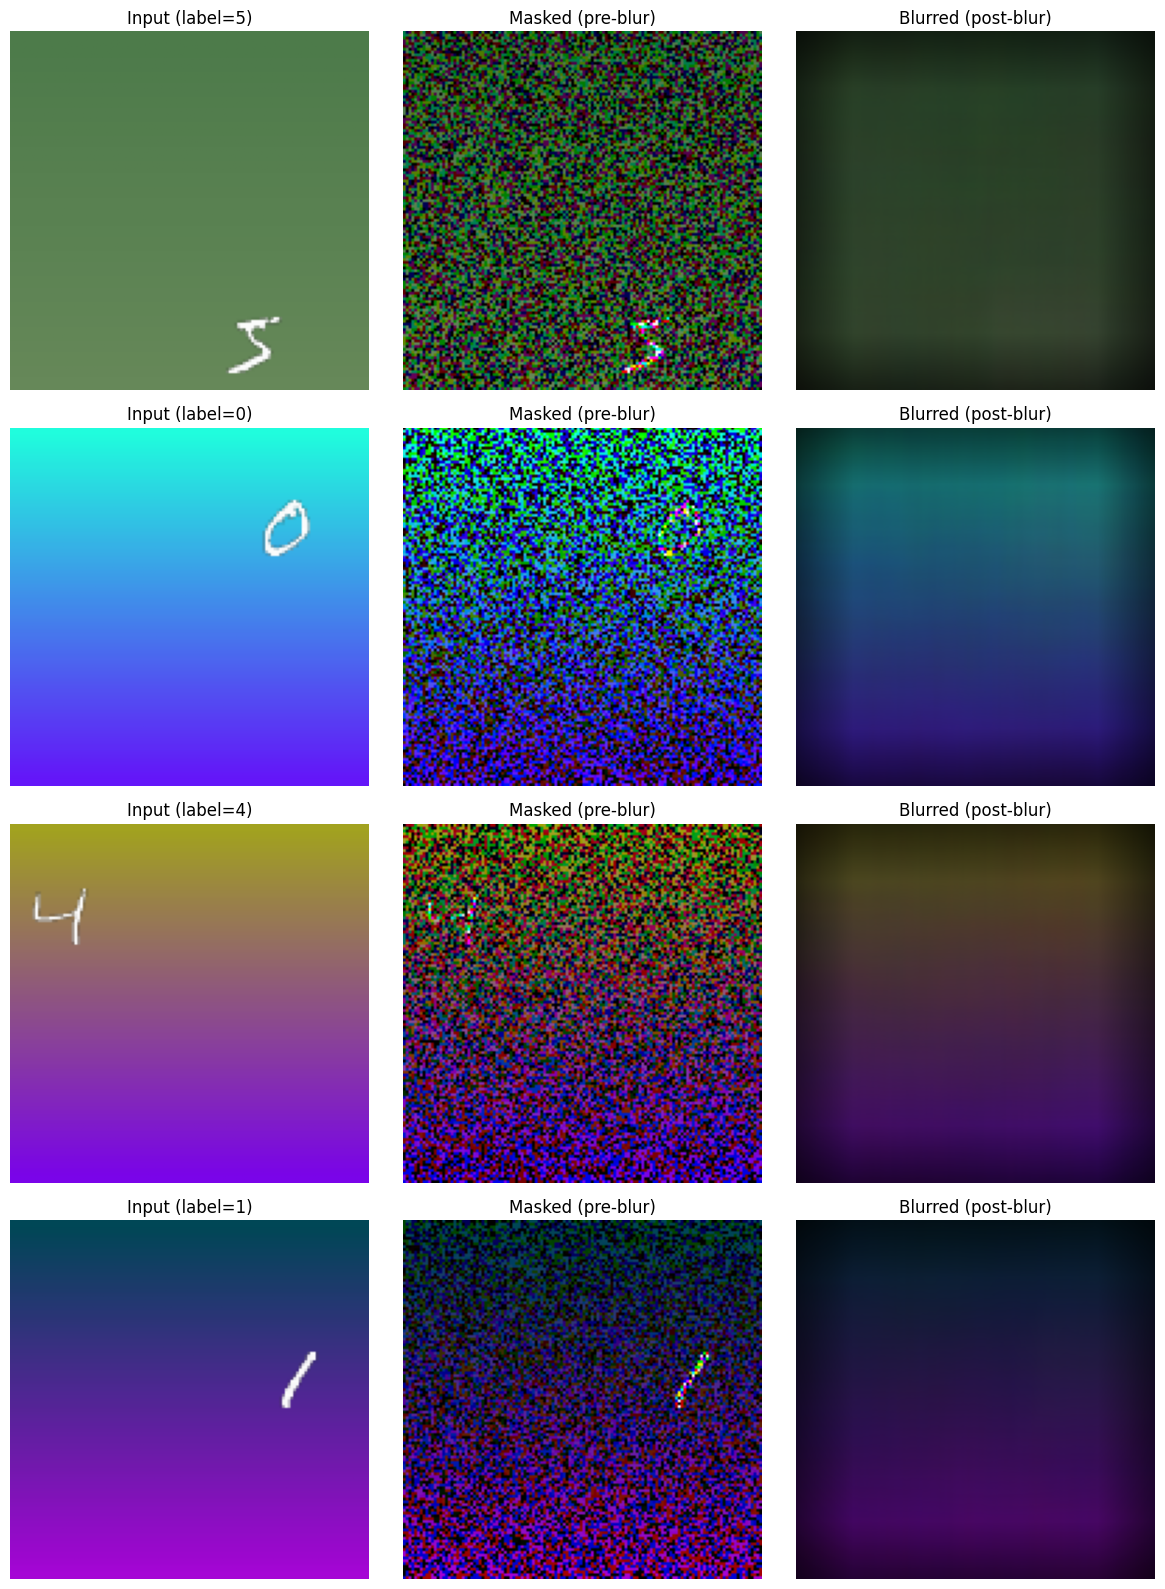


U-Net Mask examples:


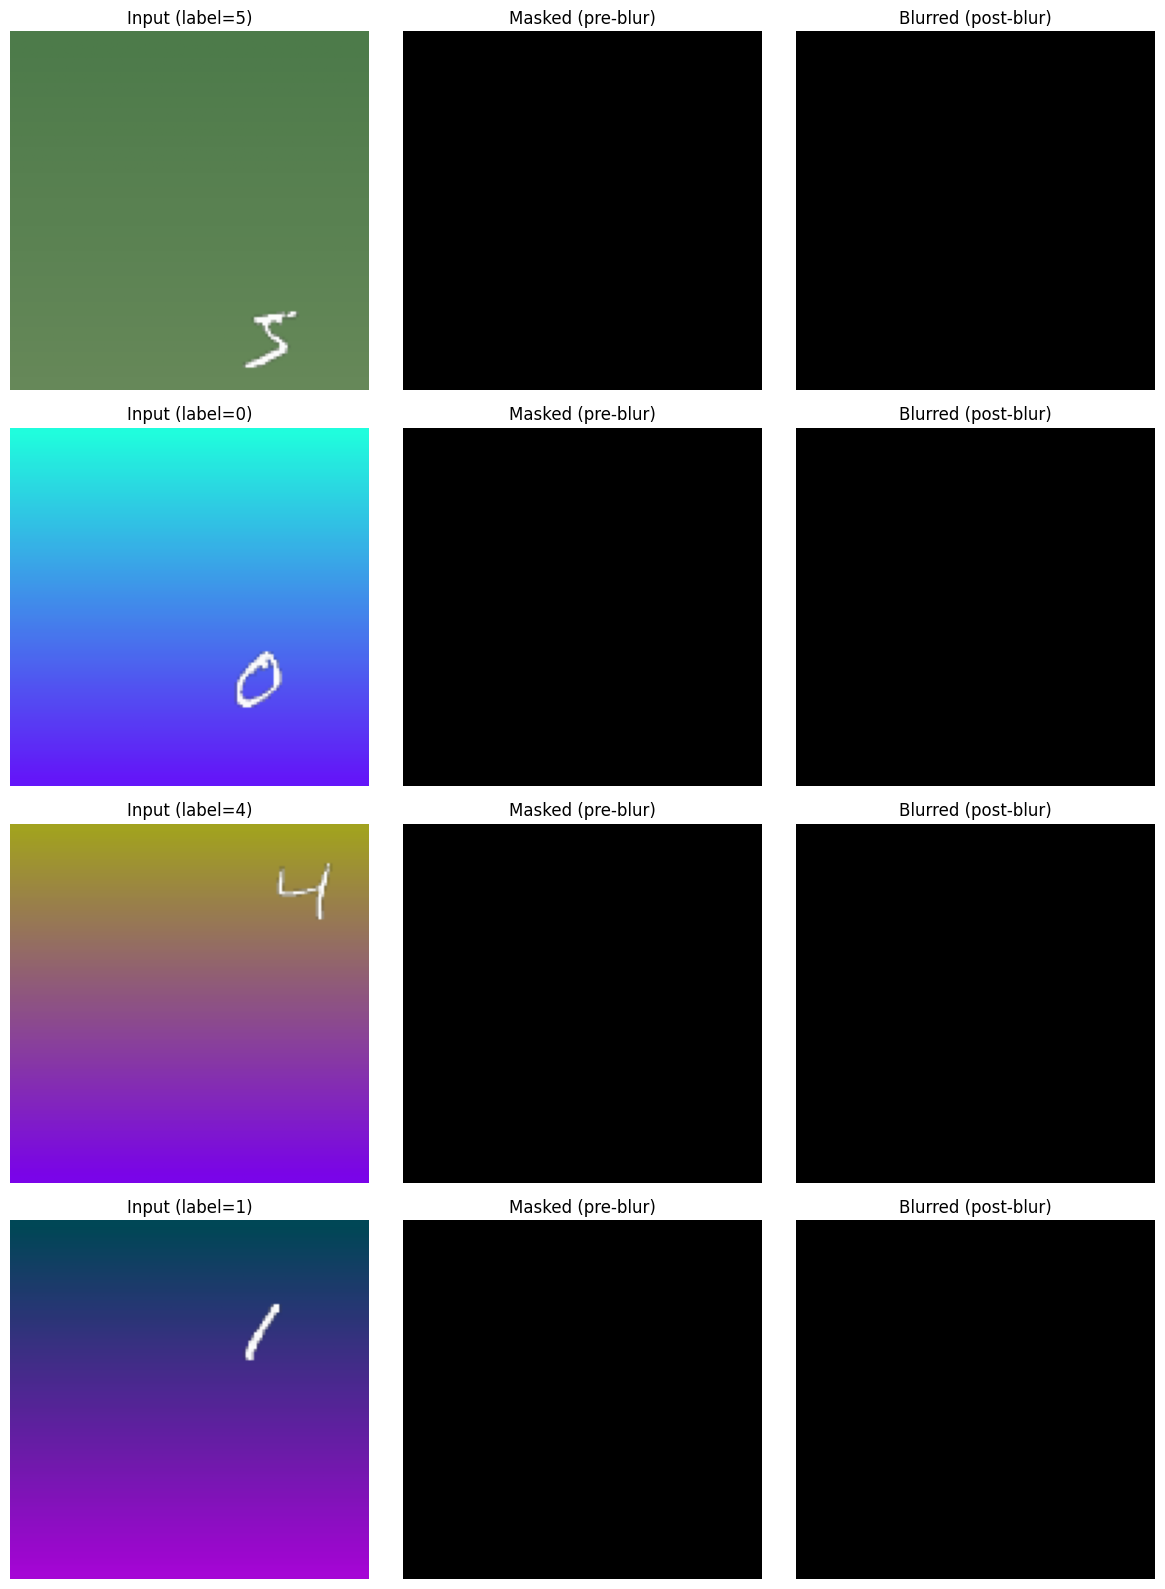

In [15]:
def show_examples(model, dataset, name, n=4):
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 4))
    for i in range(n):
        comp, label, x_off, y_off = dataset[i]
        comp_in = comp.unsqueeze(0).to(device)

        with torch.no_grad():
            masked = model(comp_in)
            blurred = box_blur(masked)

        axes[i, 0].imshow(comp.permute(1, 2, 0).clamp(0, 1))
        axes[i, 0].set_title(f"Input (label={label})")
        axes[i, 1].imshow(masked.squeeze(0).cpu().permute(1, 2, 0).clamp(0, 1))
        axes[i, 1].set_title("Masked (pre-blur)")
        axes[i, 2].imshow(blurred.squeeze(0).cpu().permute(1, 2, 0).clamp(0, 1))
        axes[i, 2].set_title("Blurred (post-blur)")
        for ax in axes[i]:
            ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"Results/Graphs/{name}_samples.png", dpi=150, bbox_inches='tight')
    plt.show()

print("Random Mask examples:")
show_examples(model_a, full_dataset, "A_random")
print("\nU-Net Mask examples:")
show_examples(model_c, full_dataset, "C_unet")

In [16]:

import shutil
import os

# Make sure you're in the right directory
# %cd /content/blur_obfuscation_project  # uncomment if needed

# Zip the entire experiment folder
# Change this path to wherever your experiment lives
EXP_NAME = "EX_02_results"

# Zip everything
shutil.make_archive(
    f'/content/{EXP_NAME}',   # output filename (without .zip)
    'zip',                      # format
    '.',                        # root directory to zip
)

# Trigger download in browser
from google.colab import files
files.download(f'/content/{EXP_NAME}.zip')

print(f"Downloading {EXP_NAME}.zip — check your browser downloads folder")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>